### **TAYLOR SWIFT**
---
##### Trabajo practico II - Procesamiento del lenguaje natural - ITBA
##### *Clusterización.*
---
Miembros del grupo:
* Magdalena Eppens - 62450
* Sofía Hanna Feilbogen - 61889
* Sofía Gonzalez del Solar - 62292
* Nicole Reiman - 62407


### 1. Librerias

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk import word_tokenize
from nltk.corpus import stopwords
from nltk.corpus import names
from nltk.stem import WordNetLemmatizer
from nltk.stem.snowball import SnowballStemmer
from collections import Counter
from textblob import TextBlob
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.feature_extraction import text
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.decomposition import LatentDirichletAllocation
from gensim.models import Word2Vec
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Masking, Dropout
import plotly.graph_objs as go
import plotly.express as px

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('names')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


### 2. Bases de datos

In [ ]:
# List of album CSV file names
albums = [
    "01-taylor_swift.csv",
    "02-fearless_taylors_version.csv",
    "03-speak_now_deluxe_package.csv",
    "04-red_deluxe_edition.csv",
    "05-1989_deluxe.csv",
    "06-reputation.csv",
    "07-lover.csv",
    "08-folklore_deluxe_version.csv",
    "09-evermore_deluxe_version.csv"
]

dataframes = []
for album in albums:
    df = pd.read_csv(album)
    df['Album'] = album.replace('.csv', '')
    dataframes.append(df)

# Juntamos todos los albumes en un solo df
merged_df = pd.concat(dataframes, ignore_index=True)

# Se eliminan caracteres especiales, numeros y espacios adicionales
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Se aplica la función de limpieza a la columna de letras
merged_df['lyric'] = merged_df['lyric'].apply(clean_text)

### 3. Lematizacion

In [ ]:
# Se realiza lematización, proceso por el cual se busca el lema de una palabra,
# asegurando que el resultado siempre sea una palabra real y considerando el contexto y la gramática.

all_names = set(names.words())
lemmatizer = WordNetLemmatizer()

def lemmatize_text_with_mapping(text):
    text = text.replace('hes', 'he')
    text = text.replace('wan', 'want')
    text = text.replace('wantna', 'want')
    text = text.replace('wantt', 'want')
    text = text.replace('cause', 'because')
    text = text.replace('youve', 'you')
    text = text.replace('youll', 'you')
    text = text.replace('youd', 'you')
    text = text.replace('youre', 'you')
    text = text.replace('ahah', 'ah')
    text = text.replace('ahahag', 'ah')
    text = text.replace('ahh', 'ah')
    text = text.replace('ahuh', 'ah')

    text = text.replace('applaud', 'applause')
    text = text.replace('asked', 'ask')
    text = text.replace('babe', 'baby')
    text = text.replace('babys', 'baby')
    text = text.replace('building', 'build')
    text = text.replace('burned', 'burn')
    text = text.replace('burnin', 'burn')
    text = text.replace('clearer', 'clear')
    text = text.replace('coast', 'coastal')
    text = text.replace('building', 'build')
    text = text.replace('burned', 'burn')

    text = text.replace('colder', 'cold')
    text = text.replace('complex', 'complicate')
    text = text.replace('confess', 'confession')
    text = text.replace('cruelty', 'cruel')
    text = text.replace('dancing', 'dance')
    text = text.replace('dancin', 'dance')
    text = text.replace('darker', 'dark')
    text = text.replace('darkest', 'dark')
    text = text.replace('darkness', 'dark')
    text = text.replace('darlin', 'darling')
    text = text.replace('deadend', 'dead')
    text = text.replace('died', 'dies')
    text = text.replace('ohoh', 'oh')
    text = text.replace('ohh', 'oh')

    no_lemmatize_words = {'dies', 'pass'}

    tokens = nltk.word_tokenize(text)
    pos_tags = nltk.pos_tag(tokens)
    pos_tag_mapping = {
        'J': nltk.corpus.wordnet.ADJ,
        'V': nltk.corpus.wordnet.VERB,
        'N': nltk.corpus.wordnet.NOUN,
        'R': nltk.corpus.wordnet.ADV
    }
    lemmatized_mapping = []
    for token, pos_tag in pos_tags:
        if token.lower() in no_lemmatize_words:
            lemmatized_token = token
        else:
            wn_pos_tag = pos_tag_mapping.get(pos_tag[0].upper(), nltk.corpus.wordnet.NOUN)
            lemmatized_token = lemmatizer.lemmatize(token, pos=wn_pos_tag)
        lemmatized_mapping.append((token, lemmatized_token))
    lemmatized_text = ' '.join(word[1] for word in lemmatized_mapping)
    return lemmatized_text, lemmatized_mapping

merged_df['lyric'] = merged_df['lyric'].apply(clean_text)
merged_df['track_title'] = merged_df['track_title'].apply(clean_text)
merged_df['album_name'] = merged_df['album_name'].apply(clean_text)

# Se crea un df por frases, y uno por canciones.
df_frases = merged_df
df_canciones = merged_df.groupby(['album_name', 'track_title', 'track_n'])['lyric'].apply(' '.join).reset_index()

# Se aplica la lematizacion
df_frases['lyric_lemmatized'], lyric_lemmatized_mapping_list = zip(*df_frases['lyric'].apply(lemmatize_text_with_mapping))
df_canciones['lyric_lemmatized'], lyric_lemmatized_mapping_list = zip(*df_canciones['lyric'].apply(lemmatize_text_with_mapping))

In [ ]:
desc =  df_canciones['lyric_lemmatized'].astype(str).tolist()

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


['because baby weve get bad blood know use mad love look you because baby weve get bad blood hey weve get problem dont think solve em really deep cut baby weve get bad blood hey think trust ruin shiny rust hit weak baby breathe rub deep salt wound like you laugh right sad think good time because baby weve get bad blood know use mad love look you because baby weve get bad blood hey weve get problem dont think solve em really deep cut baby weve get bad blood hey think wed fine get scars knife dont think past kind wound think thing catch time heal wont you come way dont sad think good time because baby weve get bad blood know use mad love look you because baby weve get bad blood hey weve get problem dont think solve em really deep cut baby weve get bad blood hey bandaids dont fix bullet hole say sorry live like live ghost bandaids dont fix bullet hole say sorry live like live ghost love like blood run cold because baby weve get bad blood know use mad love look you because baby weve get ba

In [ ]:
def letters_only(astr) :
  return astr.isalpha()


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
cleaned=[]
for story in desc:
    words=word_tokenize(story)
    text=""
    for words in word_tokenize(story):
        if (letters_only(words) and len(words)>2):
          #lemma_word=lemmatizer.lemmatize(words)
          #extra=" "+str(lemma_word)
          #text+=extra
          text+=" "+words
    cleaned.append(text)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
stop_words = set(stopwords.words('english'))
stop_words.discard('he')
stop_words.discard('she')
additional_stopwords = {'oh', 'yet', 'im', 'na', 'eh','ah'}
stop_words.update(additional_stopwords)
stop_words_list = list(stop_words)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning:

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.



### 4. CountVectorizer vc TDIDF

##### 4.1. CountVectorizer

In [ ]:
cv = CountVectorizer(ngram_range=(1,1), max_df=0.85, min_df=5, max_features=None, stop_words=stop_words_list)
TNG_cv = cv.fit_transform(desc)

# Para ver la matriz de  recuento de términos
print("Matriz de recuento de términos:")
print(TNG_cv.toarray())

Matriz de recuento de términos:
[[0 0 0 ... 0 0 0]
 [0 0 1 ... 0 0 3]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning:

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.



In [ ]:
#Tamaño del vocabulario
print(f'El vocabulario es: {cv.get_feature_names_out()}')
print(f'El tamaño del vocabulario es: {len(cv.get_feature_names_out())}')

El vocabulario es: ['afraid' 'age' 'aint' 'air' 'alcohol' 'alright' 'american' 'anymore'
 'apart' 'arm' 'ask' 'autumn' 'away' 'baby' 'bad' 'bar' 'battle' 'beat'
 'beautiful' 'bed' 'beg' 'begin' 'believe' 'beneath' 'best' 'bet' 'big'
 'black' 'blame' 'block' 'blue' 'body' 'bone' 'book' 'bout' 'boy' 'brand'
 'brave' 'break' 'breath' 'breathe' 'bright' 'bring' 'brother' 'burn'
 'burng' 'busy' 'buy' 'call' 'car' 'care' 'carry' 'catch' 'chance'
 'change' 'chase' 'choice' 'city' 'clean' 'clear' 'close' 'clothe' 'coat'
 'cold' 'color' 'come' 'conversation' 'cool' 'corner' 'couldve' 'count'
 'cover' 'crazy' 'cross' 'crowd' 'cruel' 'cry' 'curse' 'cut' 'daddy'
 'damn' 'dance' 'dark' 'darlingg' 'day' 'daydream' 'dead' 'deep' 'didnt'
 'die' 'dies' 'different' 'doesnt' 'dont' 'door' 'draw' 'dream' 'dress'
 'drink' 'drive' 'drop' 'drunk' 'easy' 'echo' 'em' 'end' 'everybody' 'eye'
 'face' 'fade' 'faith' 'fake' 'fall' 'family' 'far' 'fast' 'faster' 'fate'
 'father' 'favorite' 'fear' 'feel' 'feeling' '

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning:

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.



##### 4.2. TFIDF

In [ ]:
tfidf = TfidfVectorizer(ngram_range=(1,1), max_df=0.85, min_df=5, max_features=None, stop_words=stop_words_list)
TNG_tfidf = tfidf.fit_transform(desc)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning:

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.



In [ ]:
print(f'El vocabulario es: {tfidf.get_feature_names_out()}')
print(f'El tamaño del vocabulario es {len(tfidf.get_feature_names_out())}')

El vocabulario es: ['afraid' 'age' 'aint' 'air' 'alcohol' 'alright' 'american' 'anymore'
 'apart' 'arm' 'ask' 'autumn' 'away' 'baby' 'bad' 'bar' 'battle' 'beat'
 'beautiful' 'bed' 'beg' 'begin' 'believe' 'beneath' 'best' 'bet' 'big'
 'black' 'blame' 'block' 'blue' 'body' 'bone' 'book' 'bout' 'boy' 'brand'
 'brave' 'break' 'breath' 'breathe' 'bright' 'bring' 'brother' 'burn'
 'burng' 'busy' 'buy' 'call' 'car' 'care' 'carry' 'catch' 'chance'
 'change' 'chase' 'choice' 'city' 'clean' 'clear' 'close' 'clothe' 'coat'
 'cold' 'color' 'come' 'conversation' 'cool' 'corner' 'couldve' 'count'
 'cover' 'crazy' 'cross' 'crowd' 'cruel' 'cry' 'curse' 'cut' 'daddy'
 'damn' 'dance' 'dark' 'darlingg' 'day' 'daydream' 'dead' 'deep' 'didnt'
 'die' 'dies' 'different' 'doesnt' 'dont' 'door' 'draw' 'dream' 'dress'
 'drink' 'drive' 'drop' 'drunk' 'easy' 'echo' 'em' 'end' 'everybody' 'eye'
 'face' 'fade' 'faith' 'fake' 'fall' 'family' 'far' 'fast' 'faster' 'fate'
 'father' 'favorite' 'fear' 'feel' 'feeling' '

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning:

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.



### 5. Kmeans vs LDA

##### 5.1. K-Means

In [ ]:
number_of_clusters = 4
#TNG_cv_cleaned = cv.fit_transform(desc)
kmmodel = KMeans(n_clusters=number_of_clusters)
kmmodel.fit(TNG_tfidf)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning:

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning



KMeans(n_clusters=4)

In [ ]:
order_centroids = kmmodel.cluster_centers_.argsort()[:, ::-1]
terms = cv.get_feature_names_out()

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning:

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.



In [ ]:
for i in range(number_of_clusters):
    print("Cluster %d:" % i),
    for ind in order_centroids[i, :10]:
        print(' %s' % terms[ind])
        plt.show()

Cluster 0:
 know
 like
 love
 tell
 come
 good
 say
 ooh
 think
 baby
Cluster 1:
 time
 get
 right
 come
 love
 think
 ive
 id
 know
 baby
Cluster 2:
 dont
 want
 know
 like
 say
 look
 love
 thats
 ill
 rain
Cluster 3:
 follow
 home
 hope
 think
 stay
 say
 forever
 plan
 man
 baby


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning:

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.



##### 5.2. LDA

In [ ]:
lda = LatentDirichletAllocation(n_components=4, max_iter=5, learning_method='online', learning_offset=50.,random_state=0).fit(TNG_tfidf)
lda

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning:

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.



LatentDirichletAllocation(learning_method='online', learning_offset=50.0,
                          max_iter=5, n_components=4, random_state=0)

In [ ]:
def display_topics(model, feature_names, no_top_words):
    for topic_idx, topic in enumerate(model.components_):
        print("Topic %d:" % (topic_idx))
        print(" ".join([feature_names[i]
                        for i in topic.argsort()[:-no_top_words - 1:-1]]))

display_topics(lda, feature_names=cv.get_feature_names_out(), no_top_words=10)

Topic 0:
nice know thing baby mean begin time gon thats let
Topic 1:
grow long dont lose live wasnt say stay remember life
Topic 2:
know dont want like come love say think time ill
Topic 3:
shouldve he follow good say ill think know home forgiveness


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning:

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.



In [ ]:
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

topic_words = display_topics(lda, feature_names=tfidf.get_feature_names_out(), no_top_words=10)  # Obtener palabras
df['word'] = df.apply(lambda row: topic_words[row['topic']][row.name % len(topic_words[row['topic']])], axis=1)

fig = go.Figure()

for i in range(len(df)):
    text = df['word'][i]
    fig.add_trace(go.Scatter3d(
        x=[df['x'][i]],
        y=[df['y'][i]],
        z=[df['z'][i]],
        mode='markers',
        text=text,
        marker=dict(
            size=5,
            color=colors[df['topic'][i]],
            opacity=0.8,
        ),
        hoverinfo='text',
        hovertext=text,
        name=f'Tema {df["topic"][i]}'
    ))


fig.update_layout(
    title='Topic Modeling with LDA',
    scene=dict(
        xaxis=dict(title='Dimensión 1'),
        yaxis=dict(title='Dimensión 2'),
        zaxis=dict(title='Dimensión 3')
    ),
    margin=dict(l=0, r=0, b=0, t=40),
    hovermode='closest'
)

fig.update_traces(showlegend=False)
for i, color in enumerate(colors):
    fig.add_trace(go.Scatter3d(
        x=[None], y=[None], z=[None],
        mode='markers',
        marker=dict(color=color, size=10),
        showlegend=True,
        name=f'Cluster {i}'
    ))

fig.show()


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning:

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.



In [ ]:
TNG_topics_lda = lda.transform(TNG_tfidf)
topics=pd.DataFrame(TNG_topics_lda)
topics['max']=TNG_topics_lda.argmax(axis=1)+1
topics

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning:

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.



,0,1,2,3,max
0,0.052185,0.051446,0.845130,0.051239,3
1,0.031106,0.030981,0.907185,0.030728,3
2,0.056783,0.055467,0.832158,0.055593,3
3,0.058983,0.058153,0.824813,0.058050,3
4,0.047647,0.047216,0.858191,0.046947,3
...,...,...,...,...,...
158,0.044203,0.044432,0.867306,0.044059,3
159,0.039565,0.039552,0.880879,0.040004,3
160,0.039639,0.039632,0.880624,0.040105,3
161,0.044580,0.044527,0.866593,0.044300,3


In [ ]:
topic_words = display_topics_with_words(TNG_topics_lda, feature_names=tfidf.get_feature_names_out(), no_top_words=10)
topics['words'] = topic_words
print(topics)

            0         1         2         3  max                     words
0    0.052185  0.051446  0.845130  0.051239    3  [aint, afraid, age, air]
1    0.031106  0.030981  0.907185  0.030728    3  [aint, afraid, age, air]
2    0.056783  0.055467  0.832158  0.055593    3  [aint, afraid, air, age]
3    0.058983  0.058153  0.824813  0.058050    3  [aint, afraid, age, air]
4    0.047647  0.047216  0.858191  0.046947    3  [aint, afraid, age, air]
..        ...       ...       ...       ...  ...                       ...
158  0.044203  0.044432  0.867306  0.044059    3  [aint, age, afraid, air]
159  0.039565  0.039552  0.880879  0.040004    3  [aint, air, afraid, age]
160  0.039639  0.039632  0.880624  0.040105    3  [aint, air, afraid, age]
161  0.044580  0.044527  0.866593  0.044300    3  [aint, afraid, age, air]
162  0.042659  0.042425  0.872568  0.042349    3  [aint, afraid, age, air]

[163 rows x 6 columns]


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning:

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.



In [ ]:
data = {
    "Palabra": [],
    "Probabilidad": [],
    "Tema": []
}
def display_topics_with_probabilities(model, feature_names, no_top_words):
    topic_words_with_probabilities = []
    for topic_idx, topic in enumerate(model.components_):
        top_features_ind = topic.argsort()[:-no_top_words - 1:-1]
        top_features_probabilities = topic[top_features_ind]
        topic_words_with_probabilities.append([(feature_names[i], prob) for i, prob in zip(top_features_ind, top_features_probabilities)])
    return topic_words_with_probabilities
topic_words_with_probabilities = display_topics_with_probabilities(lda, feature_names=tfidf.get_feature_names_out(), no_top_words=20)

for topic_idx, topic in enumerate(topic_words_with_probabilities):
    for rank, (word, probability) in enumerate(topic[:3], 1):
        data["Palabra"].append(word)
        data["Probabilidad"].append(probability)
        data["Tema"].append(topic_idx)

df = pd.DataFrame(data)

                    0         1         2         3         4        5   \
Palabra           nice      know     thing      grow      long     dont   
Probabilidad  1.848955  1.520424  1.518822  1.413593  1.265022  1.18637   
Tema                 0         0         0         1         1        1   

                    6         7         8         9         10        11  
Palabra           know      dont      want  shouldve        he    follow  
Probabilidad  5.078316  5.065563  4.452921  1.635536  1.306467  1.229098  
Tema                 2         2         2         3         3         3  


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning:

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.



In [ ]:
unique_words_per_topic = topics.groupby('max')['words'].apply(lambda x: set.union(*map(set, x)))
top_unique_words_per_topic = unique_words_per_topic.apply(lambda x: list(x)[:10])

for i, words in top_unique_words_per_topic.items():
    print(f'Tema {i}: {", ".join(words)}')

Tema 1: age, aint, afraid, air
Tema 2: afraid, air, age, aint
Tema 3: age, afraid, aint, air
Tema 4: age, afraid, aint, air


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning:

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.



/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning:

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.



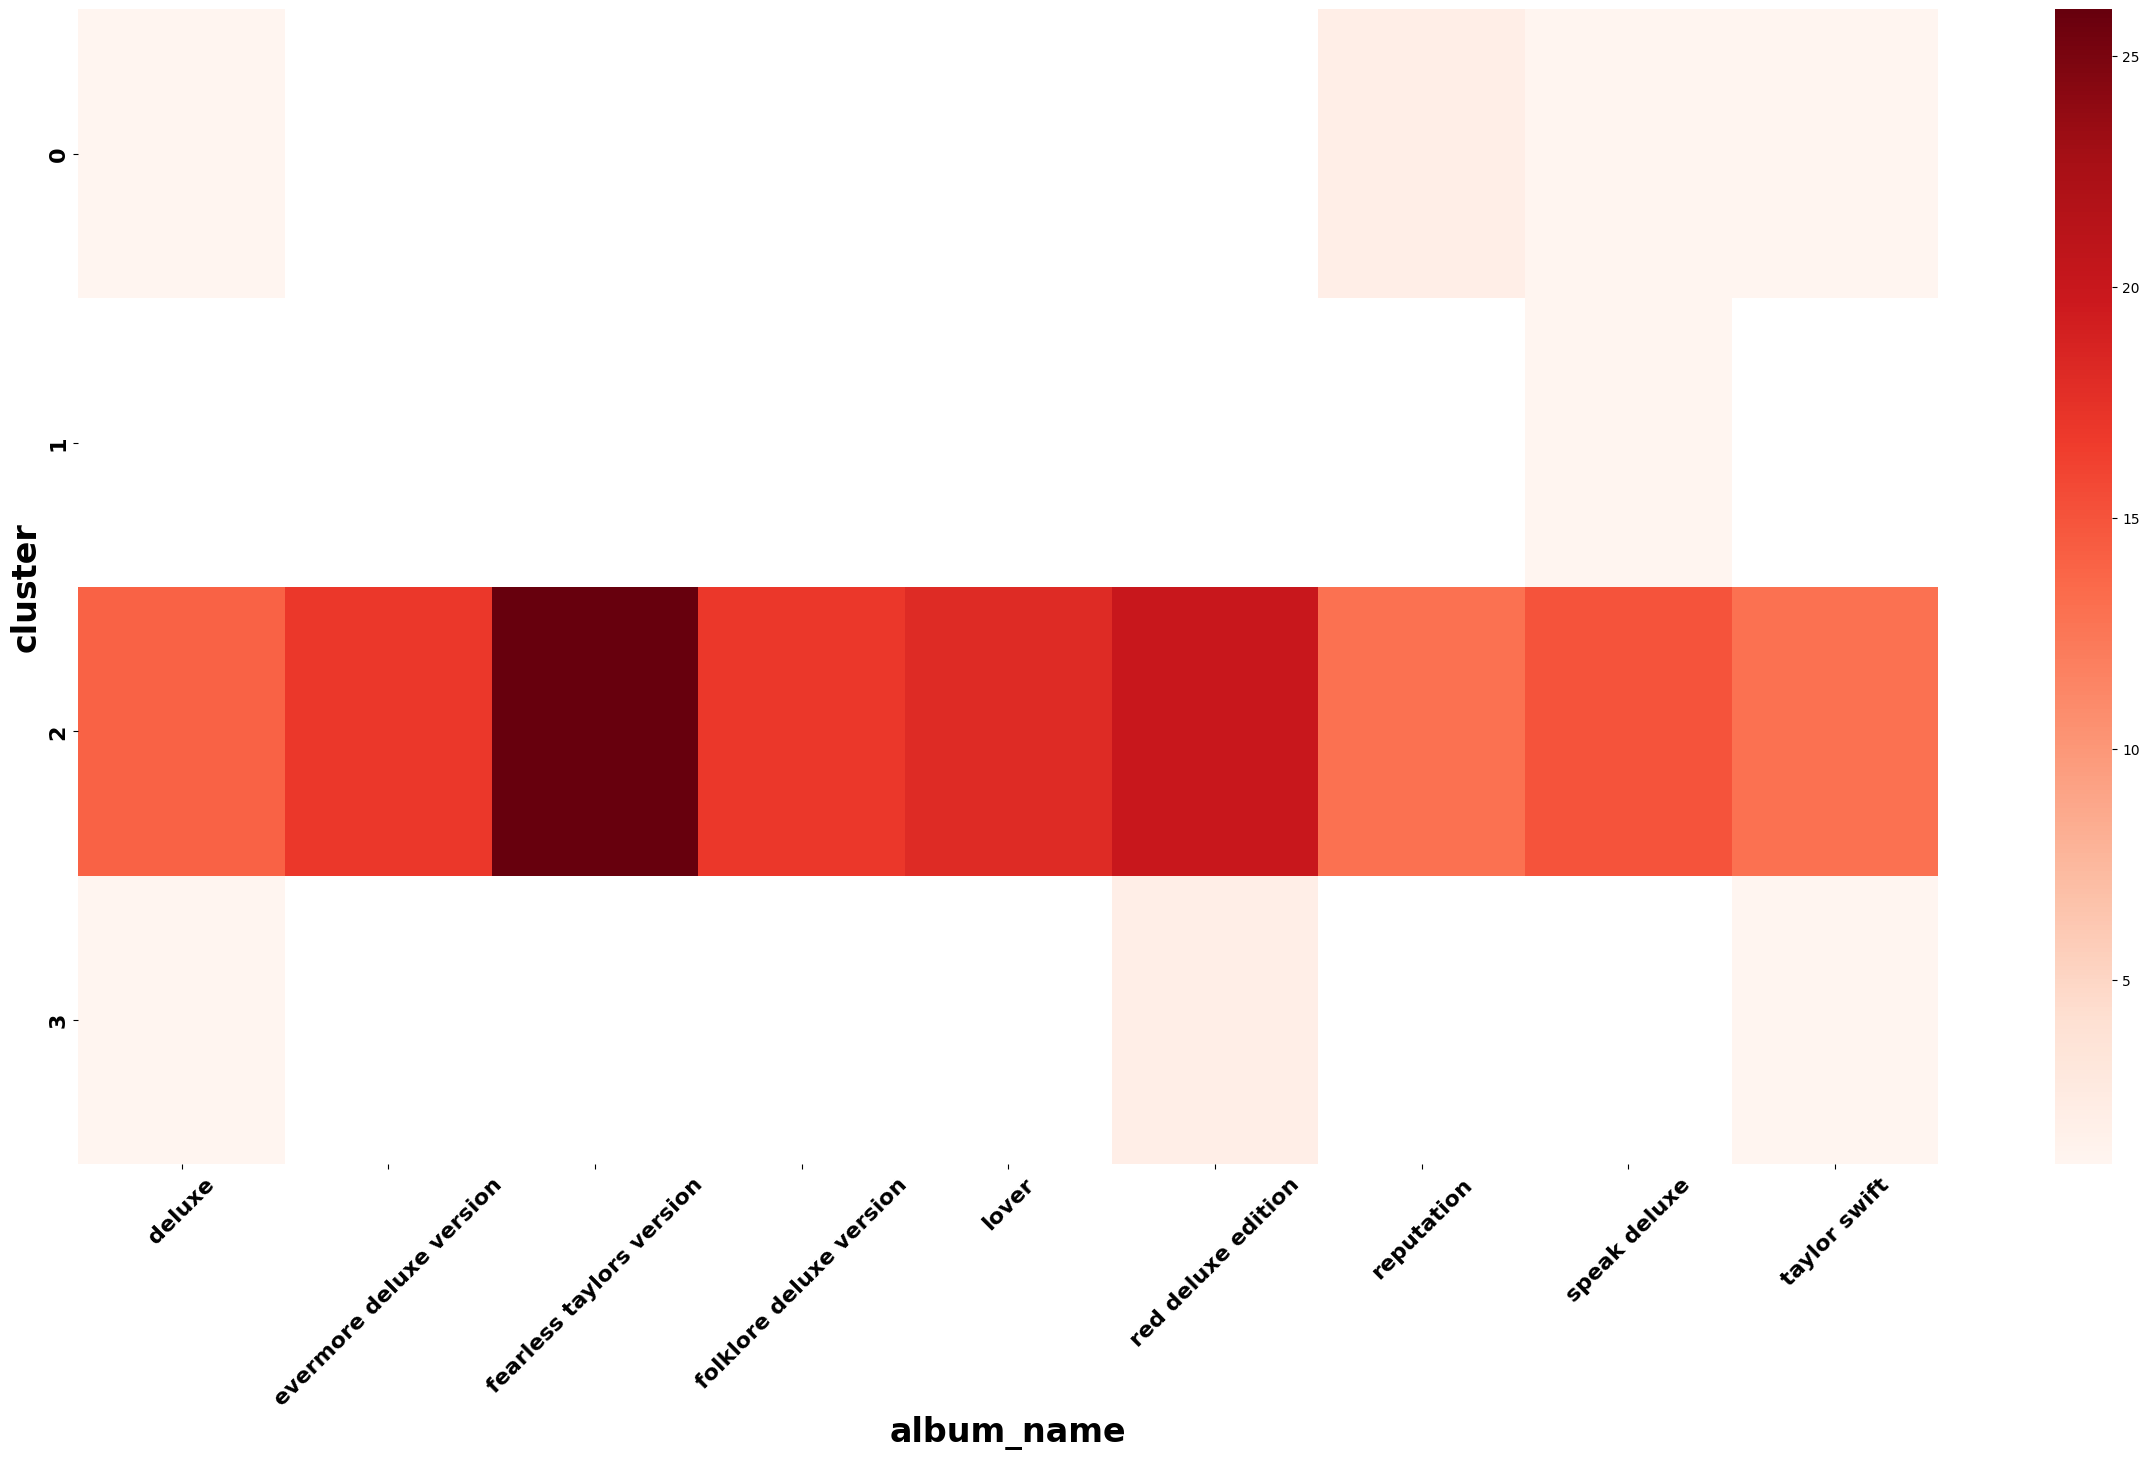

In [ ]:
document_clusters =TNG_topics_lda.argmax(axis=1)

if len(document_topic_distributions.shape) == 2 and document_topic_distributions.shape[1] > 1:
    df_canciones['cluster'] = TNG_topics_lda.argmax(axis=1)
else:
    raise ValueError("document_topic_distributions no tiene la forma esperada")

grouped_lyrics = df_canciones.groupby(['cluster', 'album_name']).size()

fig2, ax2 = plt.subplots(figsize=(30, 15))
sns.heatmap(grouped_lyrics.unstack(level='album_name'), ax=ax2, cmap='Reds')

ax2.set_xlabel('album_name', fontdict={'weight': 'bold', 'size': 24})
ax2.set_ylabel('cluster', fontdict={'weight': 'bold', 'size': 24})
for label in ax2.get_xticklabels():
    label.set_size(16)
    label.set_weight("bold")
    label.set_rotation(45)
for label in ax2.get_yticklabels():
    label.set_size(16)
    label.set_weight("bold")
plt.show()


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning:

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.



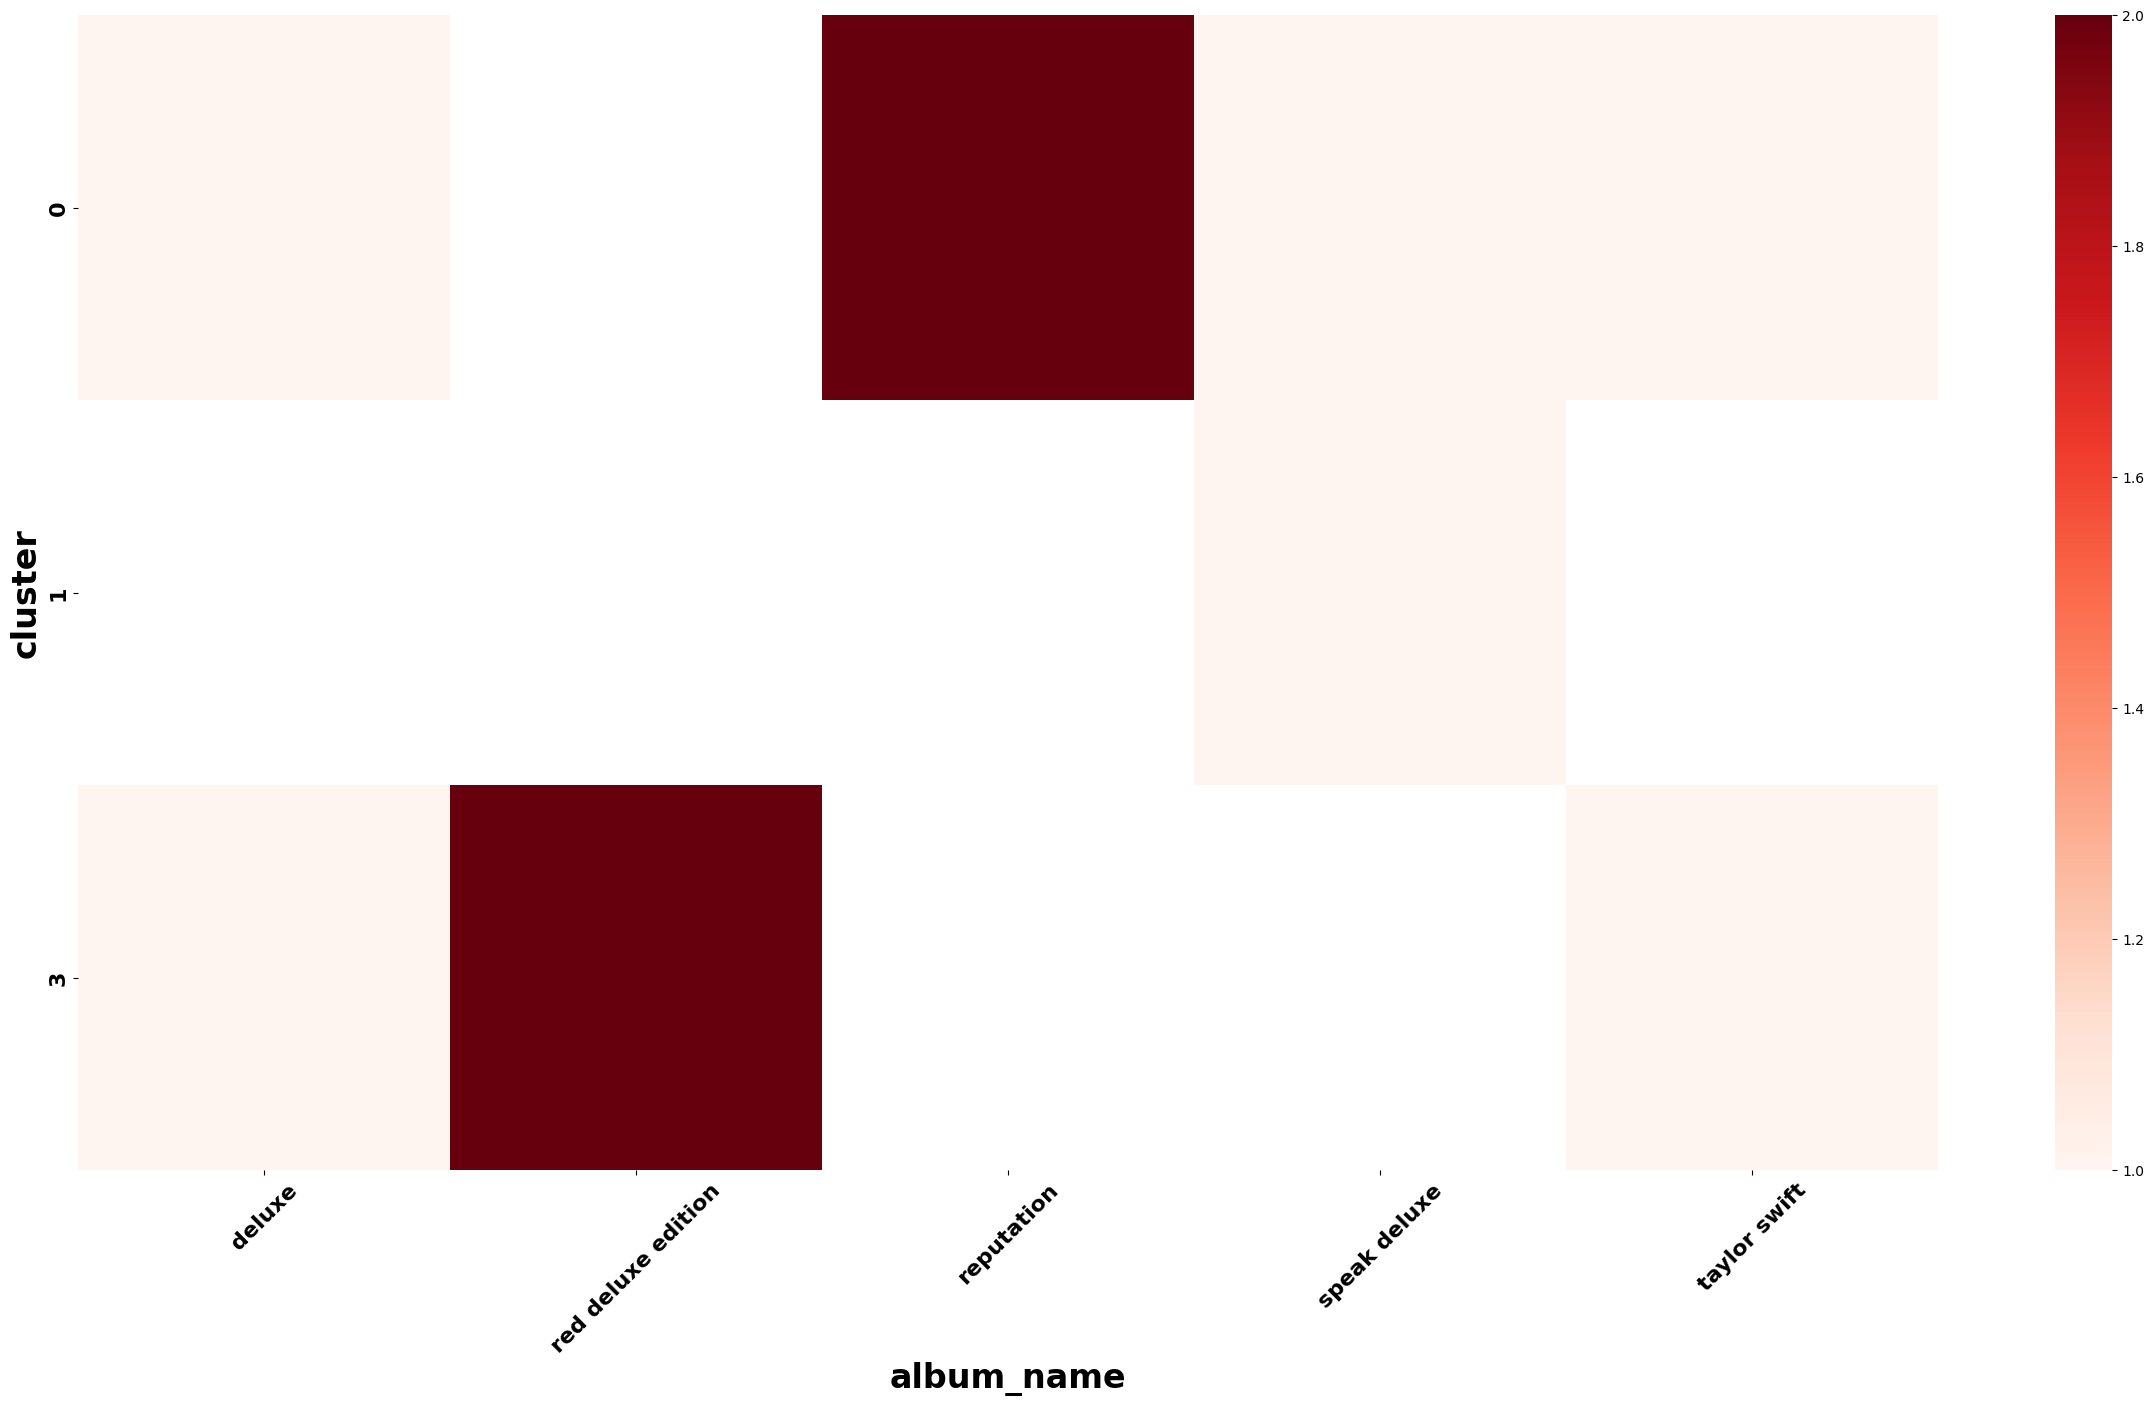

In [ ]:
df_canciones2 = df_canciones[df_canciones['cluster'] != 2]

# Agrupar por 'cluster' y 'track_title' y contar las ocurrencias
grouped_lyrics = df_canciones2.groupby(['cluster', 'album_name']).size()

fig2, ax2 = plt.subplots(figsize=(30, 15))
sns.heatmap(grouped_lyrics.unstack(level='album_name'), ax=ax2, cmap='Reds')

ax2.set_xlabel('album_name', fontdict={'weight': 'bold', 'size': 24})
ax2.set_ylabel('cluster', fontdict={'weight': 'bold', 'size': 24})
for label in ax2.get_xticklabels():
    label.set_size(16)
    label.set_weight("bold")
    label.set_rotation(45)
for label in ax2.get_yticklabels():
    label.set_size(16)
    label.set_weight("bold")
plt.show()
